# Bmad cu_inj comparison

In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

%config InlineBackend.figure_format = 'retina'

%pylab --no-import-all inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
import pytao
from pytao import Tao
from pytao.misc.markers import make_markers

import pandas as pd

from pmd_beamphysics import ParticleGroup, particle_paths
from h5py import File

import os


In [3]:
IMPACT_ARCHIVE = 'https://portal.nersc.gov/cfs/m669/lume/cu_inj/impact_cu_inj_v0_300k_particles.h5'

!wget {IMPACT_ARCHIVE}

--2022-01-14 10:41:06--  https://portal.nersc.gov/cfs/m669/lume/cu_inj/impact_cu_inj_v0_300k_particles.h5
SSL_INIT
Resolving portal.nersc.gov (portal.nersc.gov)... 128.55.206.112, 128.55.206.109, 128.55.206.106, ...
Connecting to portal.nersc.gov (portal.nersc.gov)|128.55.206.112|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102173224 (97M)
Saving to: ‘impact_cu_inj_v0_300k_particles.h5’

impact_cu_inj_v0_30 100%[===================>]  97.44M  30.8MB/s    in 3.2s    

2022-01-14 10:41:10 (30.8 MB/s) - ‘impact_cu_inj_v0_300k_particles.h5’ saved [102173224/102173224]



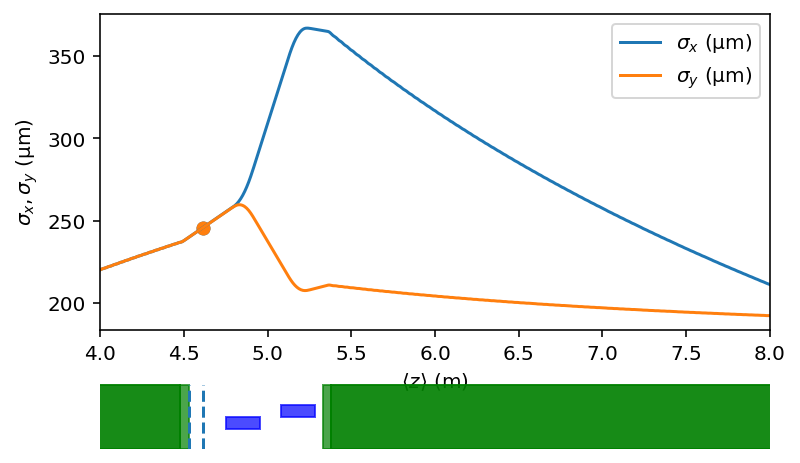

In [4]:
from impact import Impact
I = Impact.from_archive('impact_cu_inj_v0_300k_particles.h5')
I.plot(['sigma_x', 'sigma_y'], xlim=(4,8))

In [5]:
P0 = I.particles['YAG03'].resample(100000)
P0.drift_to_z()
P0.z[:] = 0
P0.t -= P0['mean_t']
#P0.pz *= 1 + 2.10841787E-03
P0['mean_p']  / 6.3997932E+07

0.9978912610346933

In [6]:
FOUT = os.path.expandvars('$LCLS_LATTICE/bmad/beams/YAG03_100k.h5')
P0.write(FOUT)

In [7]:
P0.twiss('xy')

{'alpha_x': -4.840537431917141,
 'beta_x': 17.130951969799867,
 'gamma_x': 1.426120549100833,
 'emit_x': 3.494768647122823e-09,
 'eta_x': -0.00015890137925245374,
 'etap_x': 1.8642443924500785e-05,
 'norm_emit_x': 4.3676475258119206e-07,
 'alpha_y': -4.856378871720599,
 'beta_y': 17.201899207613607,
 'gamma_y': 1.4291686893975704,
 'emit_y': 3.497810737006068e-09,
 'eta_y': -0.001496065964111138,
 'etap_y': -0.0004378710936033969,
 'norm_emit_y': 4.3714494302277655e-07}

In [8]:
slist = np.linspace(4, 16.5, 100)
make_markers(slist, 'markers.bmad');

len(slist)

100

In [9]:
tao = Tao('-init tao.init -slice YAG03:END -noplot')
names=tao.lat_ele_list()

In [10]:
%%time
tao.cmd('call SC.tao')
tao.cmd('set ele L0B phi0 = 0')
tao.cmd('beamon')
tao.cmd('beamoff')

CPU times: user 23.1 s, sys: 1.38 s, total: 24.5 s
Wall time: 9.17 s


[]

In [11]:
def bunch_at(ele):
    return ParticleGroup(data=tao.bunch_data(ele))
bunch_at('YAG03')

<ParticleGroup with 100000 particles at 0x124b36b50>

(0.0, 1e-06)

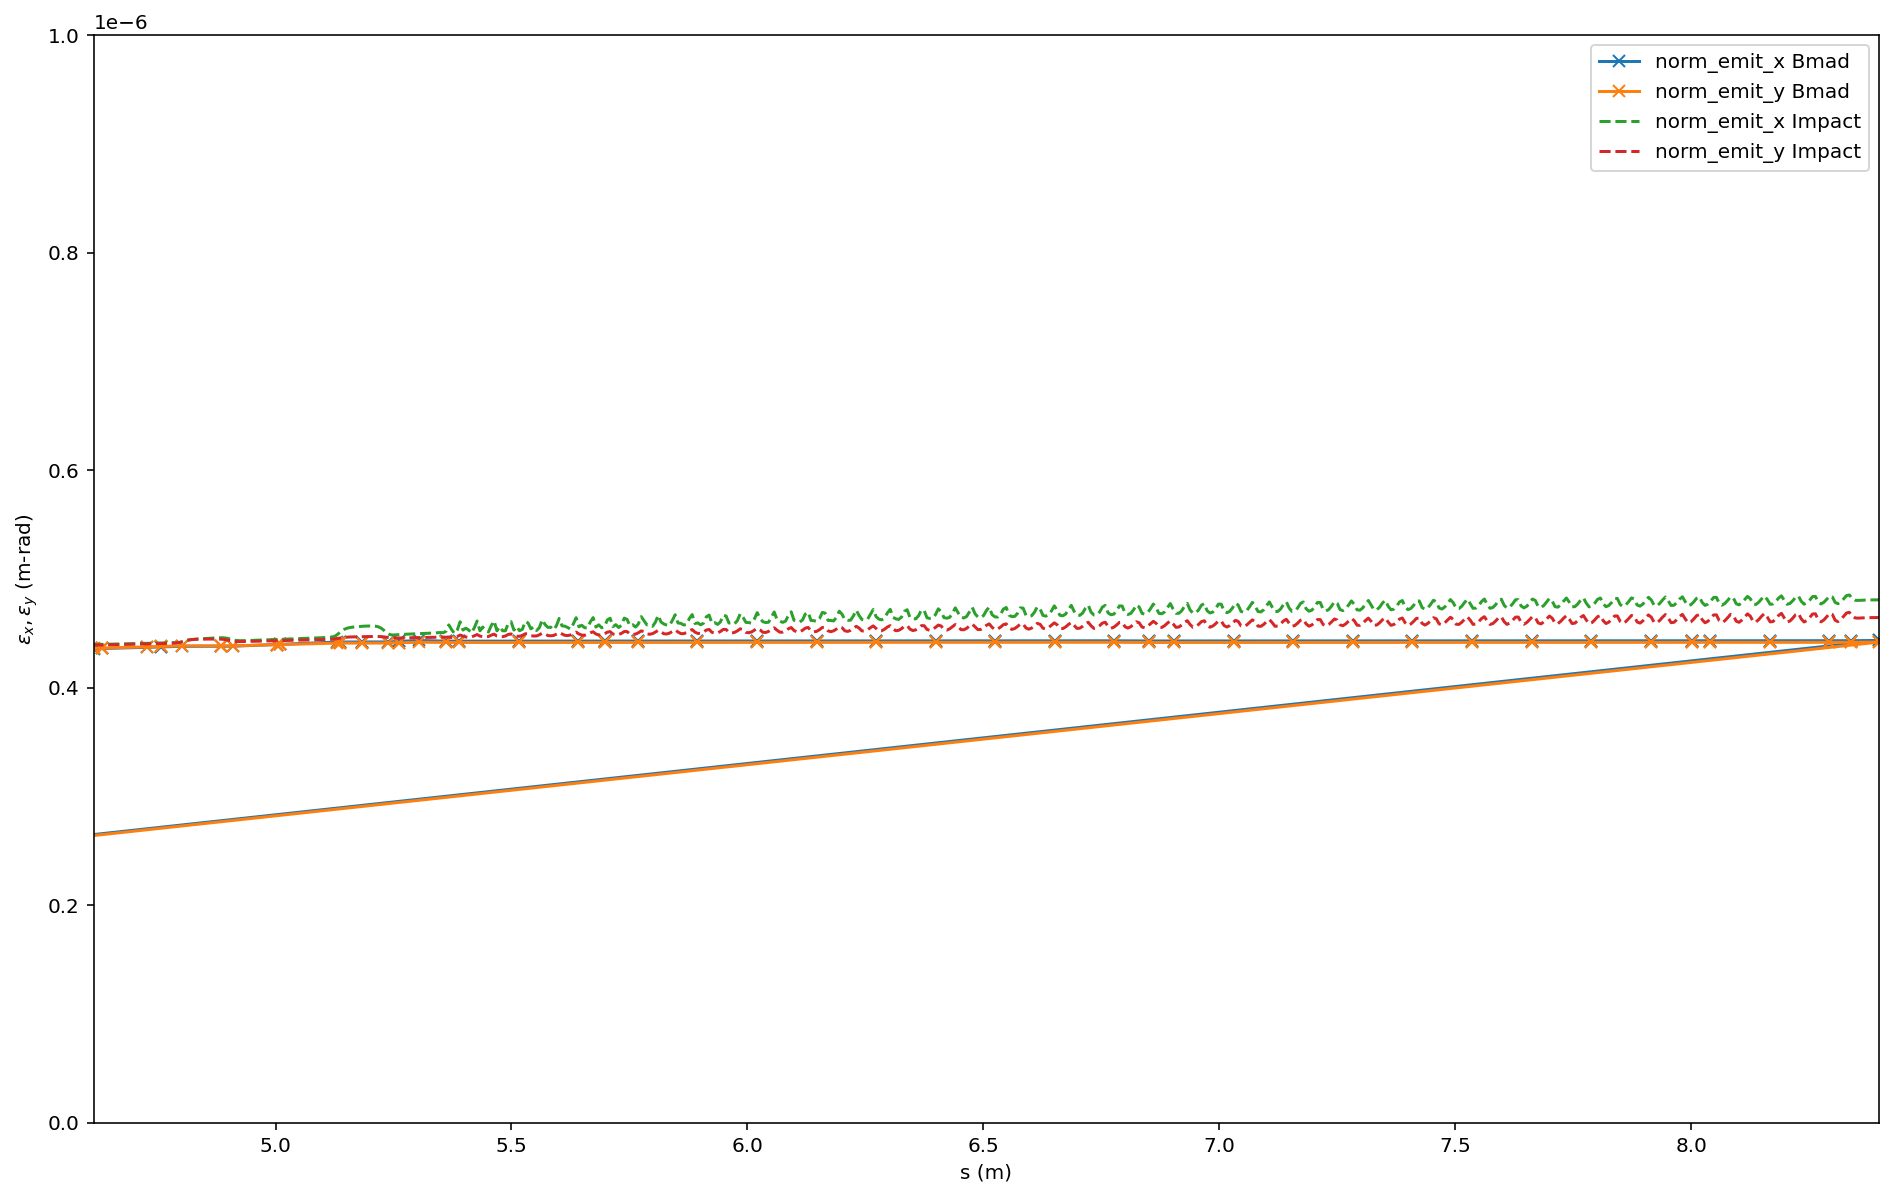

In [12]:
bdata = [dat for dat in [tao.bunch_params(ele, raises=False) for ele in names] if isinstance(dat, dict)]

df = pd.DataFrame(bdata)

fig, ax = plt.subplots(figsize=(16,10))

k1 = 'norm_emit_x'
k2 = 'norm_emit_y'

ax.plot(df.s, df[k1], label=f'{k1} Bmad', marker='x')
ax.plot(df.s, df[k2], label=f'{k2} Bmad', marker='x')
ax.plot(I.stat('mean_z'), I.stat(k1), label=f'{k1} Impact', linestyle='--')
ax.plot(I.stat('mean_z'), I.stat(k2), label=f'{k2} Impact', linestyle='--')
plt.legend()
ax.set_xlabel('s (m)')
ax.set_ylabel(r'$\epsilon_x, \epsilon_y$'+ ' (m-rad)')
 
ax.set_xlim( 4.614539, 8.398442) #YAG03 to ENDL0
ax.set_ylim(0, 0.000001)

(0.0, 0.0005)

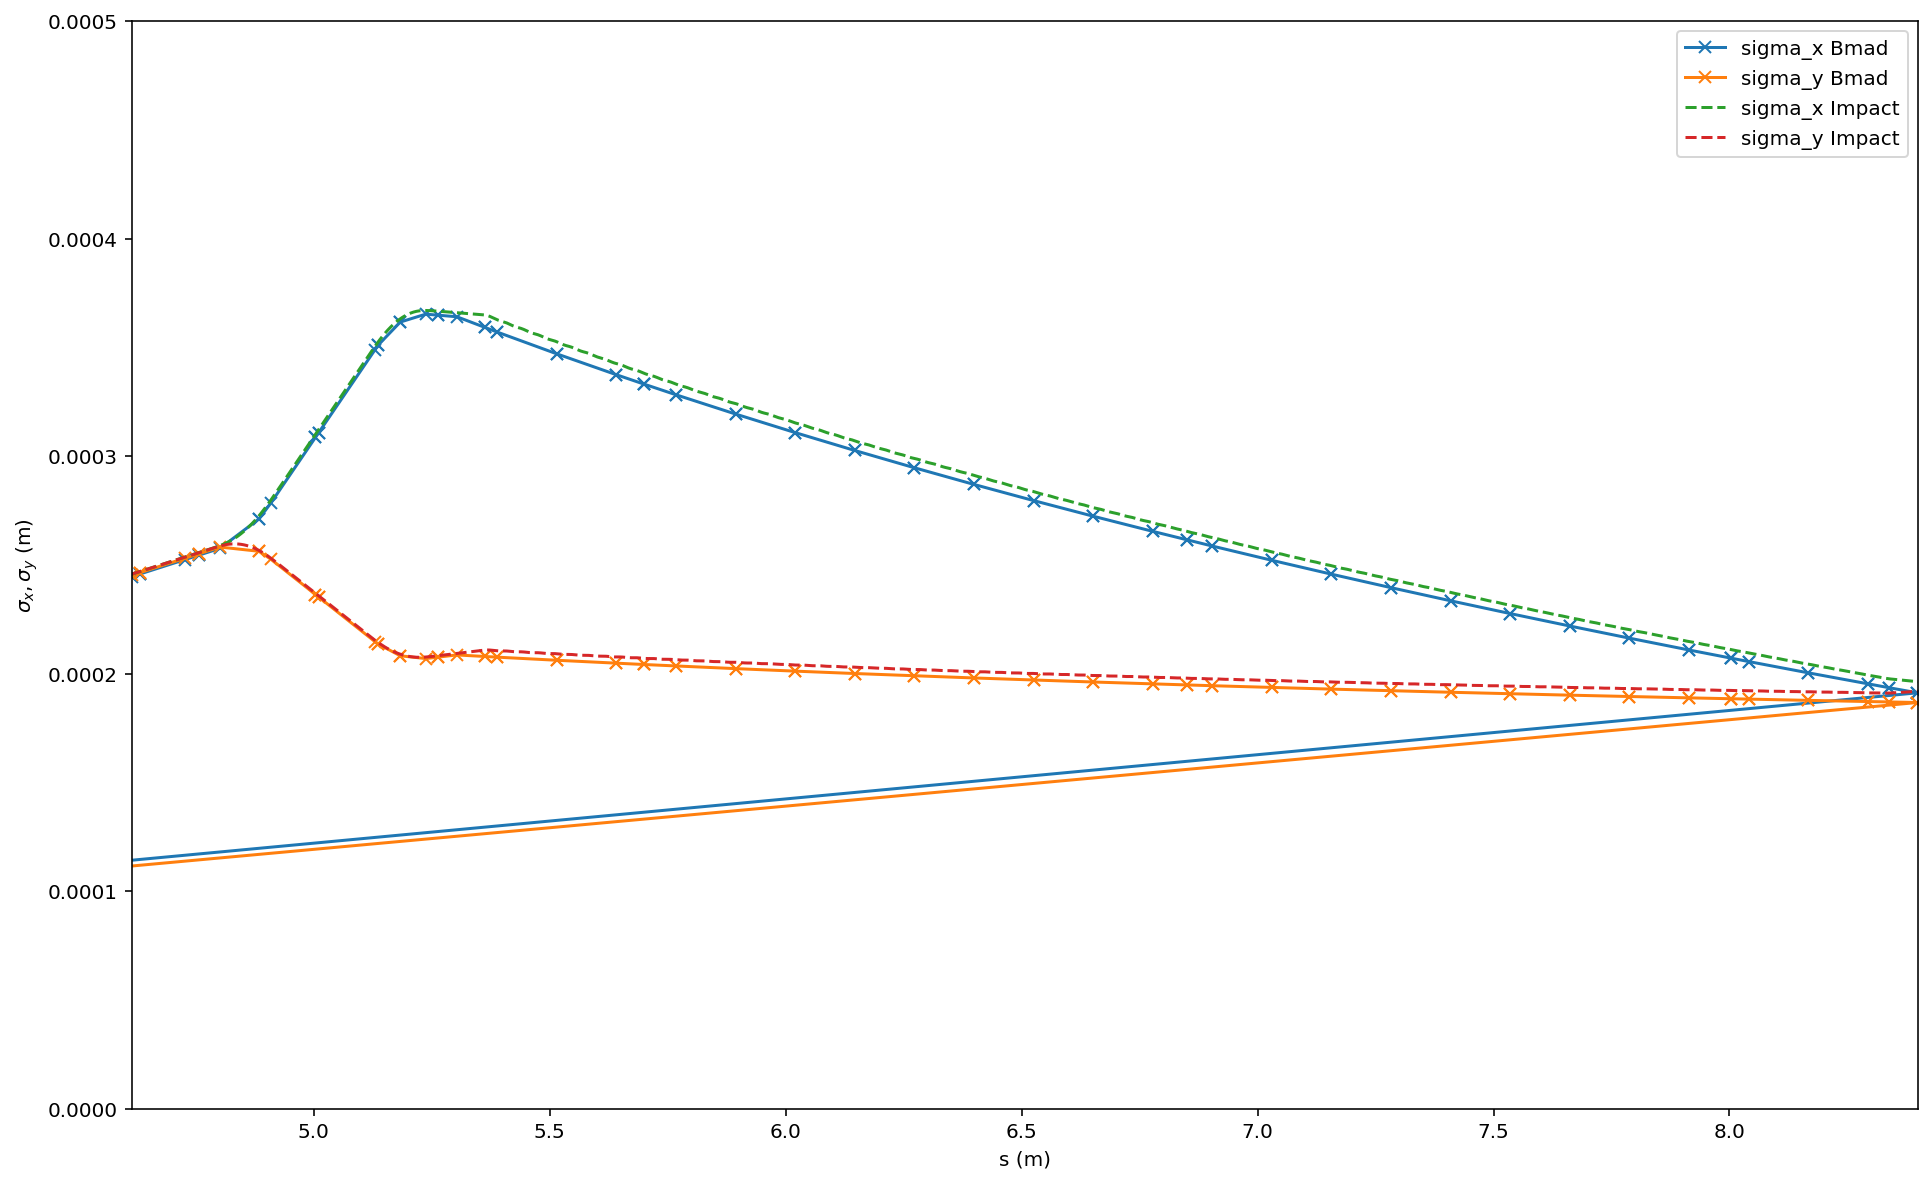

In [13]:
bdata = [dat for dat in [tao.bunch_params(ele, raises=False) for ele in names] if isinstance(dat, dict)]

df = pd.DataFrame(bdata)

fig, ax = plt.subplots(figsize=(16,10))

k1 = 'sigma_x'
k2 = 'sigma_y'


ax.plot(df.s, df[k1], label=f'{k1} Bmad', marker='x')
ax.plot(df.s, df[k2], label=f'{k2} Bmad', marker='x')
ax.plot(I.stat('mean_z'), I.stat(k1), label=f'{k1} Impact', linestyle='--')
ax.plot(I.stat('mean_z'), I.stat(k2), label=f'{k2} Impact', linestyle='--')
plt.legend()
ax.set_xlabel('s (m)')
ax.set_ylabel(r'$\sigma_x, \sigma_y$'+ ' (m)')
 
ax.set_xlim( 4.614539, 8.398442) #YAG03 to ENDL0
ax.set_ylim(0, 0.0005)

In [14]:
# Cleanup
!rm {os.path.split(IMPACT_ARCHIVE)[1]}